# Klasifikasi Mahasiswa dengan Perceptron
Nama : Farant Marchelino 
NIM  : 2024081012

> **Topik:** Perceptron sebagai Model Klasifikasi Linear — Dasar Neural Network

---

## 📋 Dataset

| No | IPK (x₁) | SKS (x₂) | Status (y) |
|----|:--------:|:--------:|:-----------:|
| 1  | 3.5      | 22       | 1 (Lulus)   |
| 2  | 2.8      | 18       | 0 (Tidak Lulus) |
| 3  | 3.2      | 20       | 1 (Lulus)   |

---

## 📐 Rumus Perceptron

$$z = w_1 x_1 + w_2 x_2 + b$$

$$y = \begin{cases} 1 & \text{jika } z \geq 0 \quad (\text{Lulus}) \\ 0 & \text{jika } z < 0 \quad (\text{Tidak Lulus}) \end{cases}$$

## 🔄 Perceptron Learning Rule

$$w_i \leftarrow w_i + \eta \cdot (y_{\text{target}} - y_{\text{pred}}) \cdot x_i$$
$$b \leftarrow b + \eta \cdot (y_{\text{target}} - y_{\text{pred}})$$

---
## 1️⃣  Import Library

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# Pengaturan tampilan tabel pandas
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)

print(' Library berhasil diimpor!')

 Library berhasil diimpor!


---
## 2️⃣  Dataset

In [2]:
# ── Membuat DataFrame ──────────────────────────────────────────
df = pd.DataFrame({
    'IPK (x1)' : [3.5, 2.8, 3.2],
    'SKS (x2)' : [22.0, 18.0, 20.0],
    'Status (y)': [1, 0, 1]
}, index=[1, 2, 3])

df['Keterangan'] = df['Status (y)'].map({1: '✅ Lulus', 0: '❌ Tidak Lulus'})

X = df[['IPK (x1)', 'SKS (x2)']].values
y = df['Status (y)'].values

print('📊 Dataset Mahasiswa:')
print('=' * 45)
df

📊 Dataset Mahasiswa:


,IPK (x1),SKS (x2),Status (y),Keterangan
1,3.5000,22.0000,1,✅ Lulus
2,2.8000,18.0000,0,❌ Tidak Lulus
3,3.2000,20.0000,1,✅ Lulus


---
## 3️⃣  Model Perceptron

In [3]:
class PerceptronModel:
    """
    Perceptron biner sederhana dengan step activation function.
    
    Parameters
    ----------
    lr        : float  — learning rate (default 0.1)
    max_epoch : int    — batas maksimum iterasi training
    """

    def __init__(self, lr=0.1, max_epoch=100):
        self.lr        = lr
        self.max_epoch = max_epoch
        self.w         = np.zeros(2)   # bobot awal = 0
        self.b         = 0.0           # bias awal  = 0
        self.log       = []            # riwayat training

    # ── Fungsi aktivasi step ────────────────────────────────────
    def aktivasi(self, z):
        return 1 if z >= 0 else 0

    # ── Prediksi satu sampel ────────────────────────────────────
    def prediksi(self, x):
        z = np.dot(self.w, x) + self.b
        return self.aktivasi(z)

    # ── Training (Perceptron Learning Rule) ─────────────────────
    def fit(self, X, y):
        for epoch in range(1, self.max_epoch + 1):
            total_error = 0
            for xi, yi in zip(X, y):
                yhat        = self.prediksi(xi)
                delta       = self.lr * (yi - yhat)
                self.w     += delta * xi
                self.b     += delta
                total_error += abs(yi - yhat)

            self.log.append({
                'Epoch'      : epoch,
                'w1'         : round(self.w[0], 4),
                'w2'         : round(self.w[1], 4),
                'b'          : round(self.b, 4),
                'Total Error': total_error
            })

            if total_error == 0:
                print(f'✅ Konvergen pada Epoch {epoch} — Total Error = 0')
                break
        else:
            print(f'⚠️  Belum konvergen setelah {self.max_epoch} epoch')


# ── Inisialisasi & Training ─────────────────────────────────────
model = PerceptronModel(lr=0.1, max_epoch=100)
model.fit(X, y)

print(f'\n📌 Bobot akhir : w1 = {model.w[0]:.4f} | w2 = {model.w[1]:.4f} | b = {model.b:.4f}')

⚠️  Belum konvergen setelah 100 epoch

📌 Bobot akhir : w1 = 0.8000 | w2 = -0.0000 | b = -1.0000


---
## 4️⃣  Tugas 2 — Hitung z dan Output Data Pertama

Menggunakan parameter soal: **w₁ = 1, w₂ = 1, b = −20**

$$z = (1)(3.5) + (1)(22) + (-20) = 5.5$$

In [8]:
# ── Parameter soal Tugas 2 ──────────────────────────────────────
w1, w2, b = 1, 1, -20
x1, x2    = 3.5, 22

z     = w1 * x1 + w2 * x2 + b
y_out = 1 if z >= 0 else 0
kelas = 'Lulus' if y_out == 1 else 'Tidak Lulus'

# ── Tampilkan perhitungan langkah demi langkah ──────────────────
print('=' * 55)
print('   STEP-BY-STEP CALCULATION: DATA PERTAMA (TUGAS 2)')
print('=' * 55)
print(f'  1. Formula     : z = w1·x1 + w2·x2 + b')
print(f'  2. Substitusi  : z = ({w1})({x1}) + ({w2})({x2}) + ({b})')
print(f'  3. Penjumlahan : z = {w1*x1} + {w2*x2} + ({b})')
print(f'  4. Hasil Akhir : z = {z}')
print(f'  5. Aktivasi    : z ≥ 0 ? Yes → y = {y_out} ({kelas})')
print('=' * 55)

# ── Tampilkan sebagai Tabel yang Dirapikan ─────────────────────
hasil = pd.DataFrame([{
    'Fitur x1 (IPK)': x1,
    'Fitur x2 (SKS)': x2,
    'Bobot w1': w1,
    'Bobot w2': w2,
    'Bias (b)': b,
    'Nilai Net (z)': z,
    'Output (y)': y_out,
    'Prediksi': kelas
}])

# Styling agar tabel lebih cantik dan mudah dibaca
styled_hasil = hasil.style.set_properties(**{
    'background-color': '#f9f9f9',
    'color': 'black',
    'border-color': 'silver',
    'text-align': 'center'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('font-weight', 'bold')]}
]).hide(axis='index')

print('\n📋 Ringkasan Hasil Tugas 2:')
display(styled_hasil)

   STEP-BY-STEP CALCULATION: DATA PERTAMA (TUGAS 2)
  1. Formula     : z = w1·x1 + w2·x2 + b
  2. Substitusi  : z = (1)(3.5) + (1)(22) + (-20)
  3. Penjumlahan : z = 3.5 + 22 + (-20)
  4. Hasil Akhir : z = 5.5
  5. Aktivasi    : z ≥ 0 ? Yes → y = 1 (Lulus)

📋 Ringkasan Hasil Tugas 2:


Fitur x1 (IPK),Fitur x2 (SKS),Bobot w1,Bobot w2,Bias (b),Nilai Net (z),Output (y),Prediksi
3.500000,22,1,1,-20,5.500000,1,Lulus


---
## 5️⃣  Riwayat Training (per Epoch)

In [9]:
df_log = pd.DataFrame(model.log)

# Tambahkan kolom keterangan konvergensi
df_log['Status'] = df_log['Total Error'].apply(
    lambda e: '✅ Konvergen' if e == 0 else '🔄 Update'
)

print('📈 Riwayat Training:')
print(f'   Total Epoch     : {len(df_log)}')
print(f'   Bobot Awal      : w1=0, w2=0, b=0')
print(f'   Bobot Akhir     : w1={df_log["w1"].iloc[-1]}, w2={df_log["w2"].iloc[-1]}, b={df_log["b"].iloc[-1]}')
print()
df_log

📈 Riwayat Training:
   Total Epoch     : 100
   Bobot Awal      : w1=0, w2=0, b=0
   Bobot Akhir     : w1=0.8, w2=-0.0, b=-1.0



,Epoch,w1,w2,b,Total Error,Status
0,1,0.0400,0.2000,0.0000,2,🔄 Update
1,2,0.0800,0.4000,0.0000,2,🔄 Update
2,3,0.1200,0.6000,0.0000,2,🔄 Update
3,4,0.1600,0.8000,0.0000,2,🔄 Update
4,5,0.2000,1.0000,0.0000,2,🔄 Update
...,...,...,...,...,...,...
95,96,0.9600,1.2000,-0.9000,2,🔄 Update
96,97,1.0000,1.4000,-0.9000,2,🔄 Update
97,98,1.0400,1.6000,-0.9000,2,🔄 Update
98,99,1.0800,1.8000,-0.9000,2,🔄 Update


---
## 6️⃣  Hasil Prediksi

In [12]:
# ── Buat DataFrame hasil prediksi ─────────────────────────────
df_hasil = df.copy()
df_hasil['z (akhir)']  = [round(np.dot(model.w, xi) + model.b, 4) for xi in X]
df_hasil['Prediksi']   = [model.prediksi(xi) for xi in X]
df_hasil['Pred Label'] = df_hasil['Prediksi'].map({1: 'Lulus', 0: 'Tidak Lulus'})
df_hasil['Benar?']     = df_hasil['Status (y)'] == df_hasil['Prediksi']

akurasi = df_hasil['Benar?'].mean() * 100
n_benar = df_hasil['Benar?'].sum()

print(f'🎯 Akurasi: {n_benar}/{len(df_hasil)} data = {akurasi:.0f}%')
print()

# ── Styling: hijau = benar, merah = salah ─────────────────────
def warnai_baris(row):
    warna = 'background-color: #000000' if row['Benar?'] else 'background-color: #000000'
    return [warna] * len(row)

df_hasil.style \
    .apply(warnai_baris, axis=1) \
    .set_caption(f'Hasil Prediksi — Akurasi: {akurasi:.0f}% ({n_benar}/{len(df_hasil)} benar)') \
    .format({'z (akhir)': '{:.4f}'})

🎯 Akurasi: 2/3 data = 67%



,IPK (x1),SKS (x2),Status (y),Keterangan,z (akhir),Prediksi,Pred Label,Benar?
1,3.500000,22.000000,1,✅ Lulus,1.8000,1,Lulus,True
2,2.800000,18.000000,0,❌ Tidak Lulus,1.2400,1,Lulus,False
3,3.200000,20.000000,1,✅ Lulus,1.5600,1,Lulus,True


---
## 7️⃣  Visualisasi

C:\Users\acer\AppData\Local\Temp\ipykernel_10520\3502578400.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


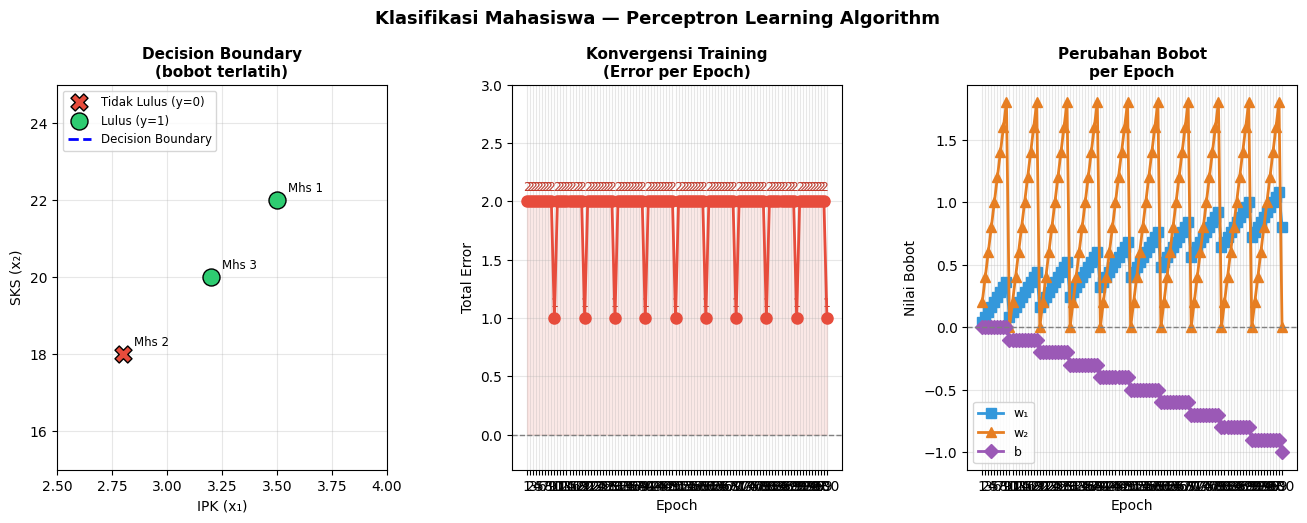


💾 Grafik disimpan sebagai perceptron_hasil.png


In [13]:
fig = plt.figure(figsize=(16, 5))
gs  = GridSpec(1, 3, figure=fig, wspace=0.38)

COLORS  = {1: '#2ecc71', 0: '#e74c3c'}
MARKERS = {1: 'o',       0: 'X'}
LBLMAP  = {1: 'Lulus (y=1)', 0: 'Tidak Lulus (y=0)'}

# ─────────────────────────────────────────────────────────────────
# Subplot 1 : Decision Boundary
# ─────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])

for cls in [0, 1]:
    idx = np.where(y == cls)[0]
    ax1.scatter(X[idx, 0], X[idx, 1],
                c=COLORS[cls], marker=MARKERS[cls],
                s=150, edgecolors='black', zorder=5, label=LBLMAP[cls])
    for i in idx:
        ax1.annotate(f'Mhs {i+1}', (X[i, 0], X[i, 1]),
                     textcoords='offset points', xytext=(8, 6), fontsize=8.5)

if model.w[1] != 0:
    x1_line = np.linspace(2.5, 3.9, 200)
    x2_line = -(model.w[0] * x1_line + model.b) / model.w[1]
    ax1.plot(x1_line, x2_line, 'b--', lw=2, label='Decision Boundary')

ax1.set_xlabel('IPK (x₁)', fontsize=10)
ax1.set_ylabel('SKS (x₂)', fontsize=10)
ax1.set_title('Decision Boundary\n(bobot terlatih)', fontsize=11, fontweight='bold')
ax1.legend(fontsize=8.5, loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(2.5, 4.0)
ax1.set_ylim(15, 25)

# ─────────────────────────────────────────────────────────────────
# Subplot 2 : Total Error per Epoch
# ─────────────────────────────────────────────────────────────────
ax2    = fig.add_subplot(gs[1])
epochs = df_log['Epoch'].tolist()
errors = df_log['Total Error'].tolist()

ax2.plot(epochs, errors, 'o-', color='#e74c3c', lw=2, markersize=8, zorder=5)
ax2.fill_between(epochs, errors, alpha=0.12, color='#e74c3c')
ax2.axhline(0, color='gray', linestyle='--', lw=1)

# Beri label nilai error di setiap titik
for ep, er in zip(epochs, errors):
    ax2.annotate(str(er), (ep, er), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=9, color='#c0392b')

ax2.set_xlabel('Epoch', fontsize=10)
ax2.set_ylabel('Total Error', fontsize=10)
ax2.set_title('Konvergensi Training\n(Error per Epoch)', fontsize=11, fontweight='bold')
ax2.set_xticks(epochs)
ax2.set_ylim(-0.3, max(errors) + 1)
ax2.grid(True, alpha=0.3)

# ─────────────────────────────────────────────────────────────────
# Subplot 3 : Perubahan Bobot per Epoch
# ─────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])

ax3.plot(epochs, df_log['w1'], 's-', color='#3498db', lw=2, markersize=7, label='w₁')
ax3.plot(epochs, df_log['w2'], '^-', color='#e67e22', lw=2, markersize=7, label='w₂')
ax3.plot(epochs, df_log['b'],  'D-', color='#9b59b6', lw=2, markersize=7, label='b')
ax3.axhline(0, color='gray', linestyle='--', lw=1)

ax3.set_xlabel('Epoch', fontsize=10)
ax3.set_ylabel('Nilai Bobot', fontsize=10)
ax3.set_title('Perubahan Bobot\nper Epoch', fontsize=11, fontweight='bold')
ax3.set_xticks(epochs)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

fig.suptitle('Klasifikasi Mahasiswa — Perceptron Learning Algorithm',
             fontsize=13, fontweight='bold', y=1.03)

plt.savefig('perceptron_hasil.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

print('\n💾 Grafik disimpan sebagai perceptron_hasil.png')